In [169]:
%run Wiskunde_II_Portfolio.ipynb

C:\Users\schur\AppData\Local\Temp\ipykernel_6228\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [171]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 200)

In [172]:
df_transformed

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,opleiding_niveau,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG,autobezit_nee,fietsbezit_nee,elektrisch_auto_nee,geslacht_vrouw,provincie_Flevoland,provincie_Friesland,provincie_Gelderland,provincie_Groningen,provincie_Limburg,provincie_Noord-Brabant,provincie_Noord-Holland,provincie_Overijssel,provincie_Utrecht,provincie_Zeeland,provincie_Zuid-Holland,burgerlijke_staat_gescheiden,burgerlijke_staat_ongehuwd,burgerlijke_staat_samenwonend,burgerlijke_staat_weduwe/weduwnaar,km_totaal,aandeel_auto,aandeel_vliegtuig,kantoor_dagen_per_jaar,hoog_uitstoot_gedrag
0,811069,50,52.66,48003.64,5,1,13266.05,2040.54,3227.95,480.71,1,20,1,7591.93,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,19015.25,0.697653,0.025280,52,14708.18
1,246882,65,64.58,55208.63,2,3,15229.89,0.00,2298.96,1423.34,0,7,2,8742.25,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,18952.19,0.803595,0.075102,0,19499.91
2,978385,49,90.87,29533.78,2,2,19853.24,1540.46,4504.21,632.48,1,2,5,4513.56,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,26530.39,0.748321,0.023840,52,21750.68
3,120468,34,80.43,44453.27,2,2,9935.50,1825.92,4407.56,1266.84,2,21,2,6904.41,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,17435.82,0.569833,0.072657,104,13736.02
4,637034,60,72.28,56497.64,2,1,16266.67,1851.07,1936.12,1676.00,5,0,1,4420.80,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,21729.86,0.748586,0.077129,260,21294.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,838823,78,85.84,28295.50,1,2,6383.24,3672.70,3085.83,1254.60,0,11,2,4251.29,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,14396.37,0.443392,0.087147,0,10147.04
1496,964501,54,85.09,45963.45,5,1,18050.72,1907.56,1247.67,907.07,1,3,2,4615.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,22113.02,0.816294,0.041020,52,20771.93
1497,659695,48,71.79,43443.92,5,2,6860.47,1568.27,1051.74,1385.12,0,13,1,4631.48,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,10865.60,0.631394,0.127478,0,11015.83
1498,883394,76,69.02,33158.29,4,1,0.00,2170.89,1978.18,364.76,0,15,1,786.82,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4513.83,0.000000,0.080809,0,1094.28


In [173]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 38 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   persoon_ID                             1500 non-null   int64  
 1   leeftijd                               1500 non-null   int64  
 2   gewicht_KG                             1500 non-null   float64
 3   jaarsalaris_eu                         1500 non-null   float64
 4   huishouden_grootte                     1500 non-null   int64  
 5   opleiding_niveau                       1500 non-null   int64  
 6   km_auto_per_jaar                       1500 non-null   float64
 7   km_fiets_per_jaar                      1500 non-null   float64
 8   km_ov_per_jaar                         1500 non-null   float64
 9   km_vliegtuig_per_jaar                  1500 non-null   float64
 10  dagen_kantoorwerken_per_week_pro_rato  1500 non-null   int64  
 11  dage

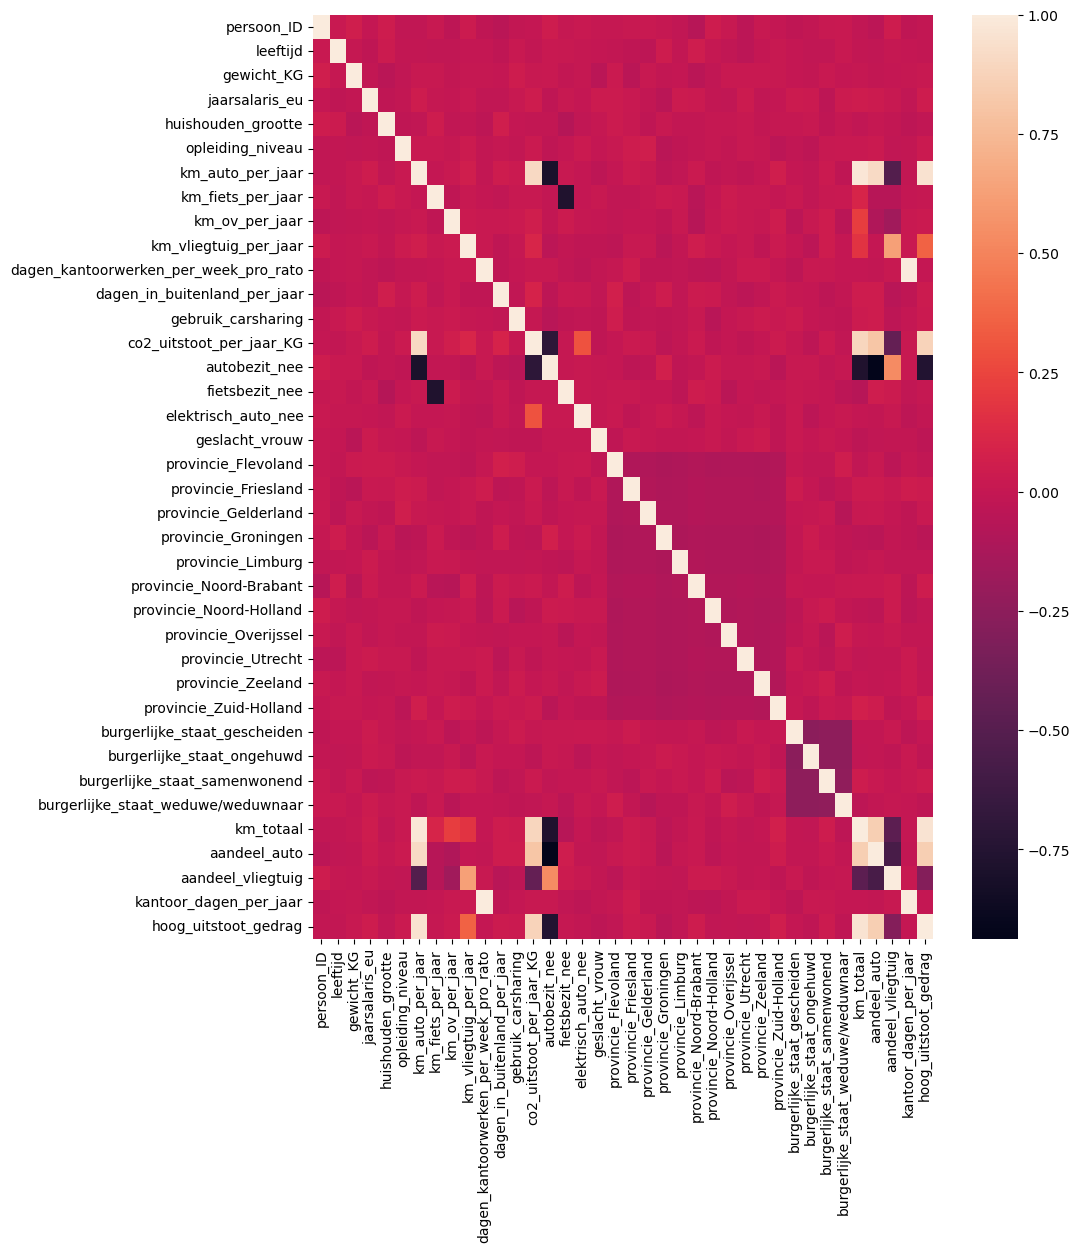

In [174]:
plt.figure(figsize=(10, 12))

sns.heatmap(df_transformed.corr())

plt.show()

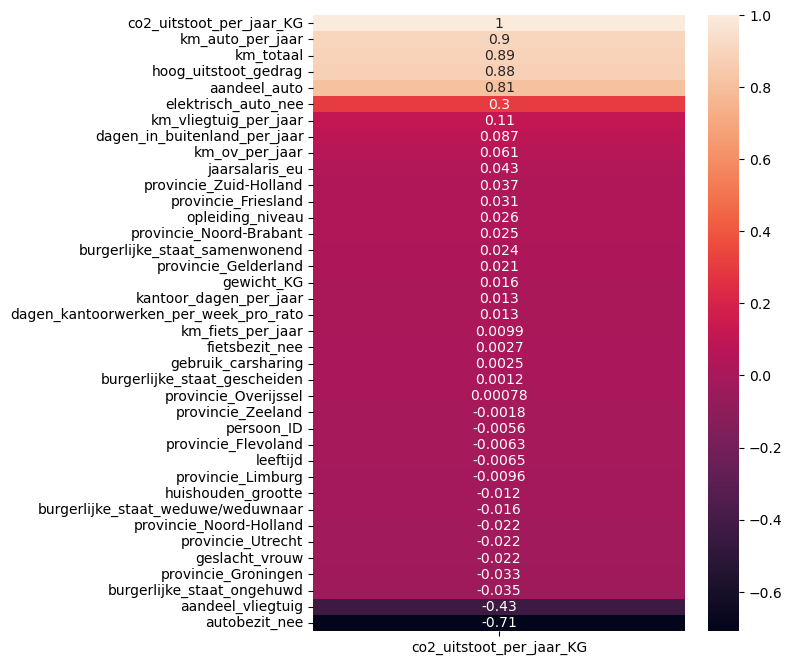

In [175]:
corr_target = df_transformed.corrwith(df_transformed['co2_uitstoot_per_jaar_KG']).sort_values(ascending=False).to_frame(name='co2_uitstoot_per_jaar_KG')

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True)

plt.show()

In [176]:
X = df_transformed.drop(['co2_uitstoot_per_jaar_KG', 'persoon_ID'], axis=1)
y = df_transformed['co2_uitstoot_per_jaar_KG']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.25)





In [177]:
from sklearn.linear_model import LinearRegression


In [178]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_val, y_val)

0.9083631094363305

In [179]:
mediaan_cols

['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [180]:
print('hallo')
_

hallo


['leeftijd',
 'gewicht_KG',
 'jaarsalaris_eu',
 'km_auto_per_jaar',
 'km_fiets_per_jaar',
 'km_ov_per_jaar',
 'km_vliegtuig_per_jaar',
 'co2_uitstoot_per_jaar_KG',
 'huishouden_grootte',
 'dagen_in_buitenland_per_jaar',
 'dagen_kantoorwerken_per_week_pro_rato']

In [181]:
mediaan_cols.remove('co2_uitstoot_per_jaar_KG')

scaler = StandardScaler()

X_train[mediaan_cols] = scaler.fit_transform(X_train[_])
X_val[mediaan_cols] = scaler.transform(X_val[_])
X_test[mediaan_cols] = scaler.transform(X_test[_])



In [184]:
lr = LinearRegression()

model = lr.fit(X_train, y_train)
y_pred = model.predict(X_val)

model.score(X_test, y_test)

0.9345731899434266